In [1]:
# Import initial libraries
import pandas as pd
import numpy as np
import boto3
from io import StringIO
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load your modeling dataset from S3
# Replace the path below with your actual S3 path from Day 26
s3 = boto3.client('s3')
bucket_name = 'cmse495-lambjos3-nyc311-381491926400-us-east-1-an'
file_name = 'modeling/resolution_time_modeling.csv'

obj = s3.get_object(Bucket=bucket_name, Key=file_name)
data = obj['Body'].read().decode('utf-8')
df = pd.read_csv(StringIO(data))

print(f"Shape: {df.shape}")
df.head()

Shape: (173851, 8)


,agency,borough,problem,incident_zip,day_of_week,hour_of_day,same_day_complaint_volume,days_to_close
0,DCWP,STATEN ISLAND,Consumer Complaint,10309.0,6,9,17,31
1,DCWP,QUEENS,Consumer Complaint,11418.0,6,13,17,1
2,DCWP,BROOKLYN,Consumer Complaint,11203.0,6,22,17,45
3,DCWP,BROOKLYN,Consumer Complaint,11233.0,6,12,17,1
4,DCWP,MANHATTAN,Consumer Complaint,10019.0,6,11,17,31


In [3]:
# Quick data check — confirm the shape, column names, and target variable
print("Columns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)

Columns: ['agency', 'borough', 'problem', 'incident_zip', 'day_of_week', 'hour_of_day', 'same_day_complaint_volume', 'days_to_close']

Missing values:
agency                          0
borough                         0
problem                         0
incident_zip                 1765
day_of_week                     0
hour_of_day                     0
same_day_complaint_volume       0
days_to_close                   0
dtype: int64

Data types:
agency                        object
borough                       object
problem                       object
incident_zip                 float64
day_of_week                    int64
hour_of_day                    int64
same_day_complaint_volume      int64
days_to_close                  int64
dtype: object


In [4]:
# Define feature columns and target column
# Replace these with your actual column names
df['fast_close'] = (df['days_to_close'] <= 3).astype(int)

feature_cols = ['incident_zip', 'day_of_week', 'hour_of_day', 'same_day_complaint_volume']
target_col = 'fast_close'

# If your target needs to be binarized or modified in some way, do it here
df['incident_zip'] = df['incident_zip'].fillna(df['incident_zip'].median())

X = df[feature_cols]
y = df[target_col]

print(f"Features: {feature_cols}")
print(f"Target: {target_col}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nClass balance: {y.value_counts(normalize=True).round(3).to_dict()}")

Features: ['incident_zip', 'day_of_week', 'hour_of_day', 'same_day_complaint_volume']
Target: fast_close

Target distribution:
fast_close
1    146139
0     27712
Name: count, dtype: int64

Class balance: {1: 0.841, 0: 0.159}


In [5]:
# Import train_test_split for splitting the data
from sklearn.model_selection import train_test_split

# Train/test split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Test set:      {X_test.shape[0]} rows")
print(f"\nClass balance in training set:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nClass balance in test set:")
print(y_test.value_counts(normalize=True).round(3))

Training set:  139080 rows
Test set:      34771 rows

Class balance in training set:
fast_close
1    0.841
0    0.159
Name: proportion, dtype: float64

Class balance in test set:
fast_close
1    0.841
0    0.159
Name: proportion, dtype: float64


In [7]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# --- Updated feature columns (include categorical) ---
# --- Rebuild X with ALL features ---
feature_cols = [
    'agency',
    'borough',
    'problem',
    'incident_zip',
    'day_of_week',
    'hour_of_day',
    'same_day_complaint_volume'
]

# fill missing first
df['incident_zip'] = df['incident_zip'].fillna(df['incident_zip'].median())

X = df[feature_cols]
y = df['fast_close']

# --- Re-split ---
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Now this will work ---
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

# --- Build transformer ---
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols),
    ]
)

# --- Fit on training only ---
X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc  = preprocessor.transform(X_test)

# --- Feature names ---
ohe_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
encoded_feature_names = ohe_names + num_cols

print(f"\nEncoded feature matrix shape: {X_train_enc.shape}")
print(f"Total features after encoding: {len(encoded_feature_names)}")
print(f"\nFirst few encoded feature names: {encoded_feature_names[:10]}")


Encoded feature matrix shape: (139080, 164)
Total features after encoding: 164

First few encoded feature names: ['agency_DEP', 'agency_DHS', 'agency_DOB', 'agency_DOE', 'agency_DOHMH', 'agency_DOT', 'agency_DPR', 'agency_DSNY', 'agency_HPD', 'agency_NYPD']


/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [9]:
# Import the logistic regression model
from sklearn.linear_model import LogisticRegression

# Train the logistic regression baseline (adjust the model type and parameters as needed for your specific task)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_enc, y_train)

print("Model trained successfully.")
print(f"Classes: {model.classes_}")

# Inspect the model coefficients
# After encoding, use encoded_feature_names instead of feature_cols
coef_df = pd.DataFrame({
    'feature': encoded_feature_names,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', ascending=False)

print("Model coefficients (top 10 by magnitude):")
print(coef_df.head(10).to_string(index=False))
print("\nPositive coefficient = feature pushes toward the positive class")
print("Negative coefficient = feature pushes toward the negative class")

Model trained successfully.
Classes: [0 1]
Model coefficients (top 10 by magnitude):
                         feature  coefficient
                     agency_NYPD     7.213292
      problem_Vendor Enforcement     3.668049
      problem_Indoor Air Quality     3.304618
           problem_Lost Property     3.297423
problem_Traffic Signal Condition     2.592400
   problem_Real Time Enforcement     2.548335
          problem_HEAT/HOT WATER     2.427380
      problem_Water Conservation     2.395267
         problem_Illegal Parking     2.303586
                problem_Day Care     1.658131

Positive coefficient = feature pushes toward the positive class
Negative coefficient = feature pushes toward the negative class


Accuracy:  0.883
Precision: 0.904
Recall:    0.963


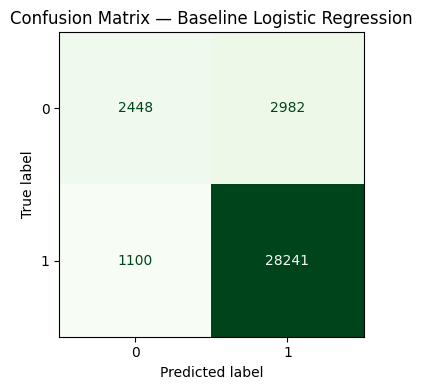

Confusion matrix saved to confusion_matrix.png


In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Generate predictions on the test set
y_pred = model.predict(X_test_enc)

# Compute metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")

# Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Confusion Matrix — Baseline Logistic Regression')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120)
plt.show()
print("Confusion matrix saved to confusion_matrix.png")